In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Load Pascal VOC 2008 Dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.VOCDetection(root="data", year="2008", image_set="train", transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

100%|██████████| 577M/577M [00:29<00:00, 19.6MB/s]


In [ ]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.layers import Flatten,Dense,Conv2D, MaxPooling2D, Conv2DTranspose, Dropout, Input,UpSampling2D,BatchNormalization,Activation
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, jaccard_score
from sklearn.metrics import average_precision_score, accuracy_score
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score, accuracy_score,precision_recall_fscore_support, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

DATASET_PATH = "/content/data/VOCdevkit/VOC2008"
IMAGE_DIR = os.path.join(DATASET_PATH, "JPEGImages")
ANN_DIR = os.path.join(DATASET_PATH, "Annotations")
SPLIT_FILE = os.path.join(DATASET_PATH, "ImageSets/Main/train.txt")
IMG_SIZE =128
SEG_DIR = os.path.join(DATASET_PATH, "SegmentationClass")


VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}
# print(len(class_to_idx))

In [ ]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt


IMG_SIZE = 128
NUM_CLASSES = 21

def load_data(img_file):
    img_path = os.path.join(IMAGE_DIR, img_file)
    mask_path = os.path.join(SEG_DIR, img_file.replace(".jpg", ".png"))

    if not os.path.exists(mask_path):
        return None, None

    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img) / 255.0

    mask = load_img(mask_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale")
    mask = img_to_array(mask).astype("uint8")

    mask = np.clip(mask, 0, NUM_CLASSES - 1)

    return img, mask

image_files = os.listdir(IMAGE_DIR)
X_data, Y_data = [], []

for file in image_files:
    img, mask = load_data(file)
    if img is not None and mask is not None:
        X_data.append(img)
        Y_data.append(mask)

X_data = np.array(X_data)
Y_data = np.array(Y_data)
Y_data = to_categorical(Y_data, num_classes=NUM_CLASSES)


print(f"{len(X_data)} training samples imagesX, masksY.")
# print(X_data[:10])


1023 training samples imagesX, masksY.


In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import jaccard_score

def createModel():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    cnn_L1 = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    cnn_L1 = Conv2D(64, (3,3), activation='relu', padding='same')(cnn_L1)
    p1 = MaxPooling2D(pool_size=(2,2))(cnn_L1)

    cnn_L2 = Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    cnn_L2 = Conv2D(128, (3,3), activation='relu', padding='same')(cnn_L2)
    p2 = MaxPooling2D(pool_size=(2,2))(cnn_L2)

    cnn_L3 = Conv2D(256, (3,3), activation='relu', padding='same')(p2)
    cnn_L3 = Conv2D(256, (3,3), activation='relu', padding='same')(cnn_L3)
    p3 = MaxPooling2D(pool_size=(2,2))(cnn_L3)

    cnn_L4 = Conv2D(512, (3,3), activation='relu', padding='same')(p3)
    cnn_L4 = Conv2D(512, (3,3), activation='relu', padding='same')(cnn_L4)

    up5 = Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(cnn_L4)
    merge5 = tf.keras.layers.concatenate([cnn_L3, up5], axis=-1)
    cnn_L5 = Conv2D(256, (3,3), activation='relu', padding='same')(merge5)

    up6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(cnn_L5)
    merge6 = tf.keras.layers.concatenate([cnn_L2, up6], axis=-1)
    cnn_L6 = Conv2D(128, (3,3), activation='relu', padding='same')(merge6)

    up7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(cnn_L6)
    merge7 = tf.keras.layers.concatenate([cnn_L1, up7], axis=-1)
    cnn_L7 = Conv2D(64, (3,3), activation='relu', padding='same')(merge7)
    outputs = Conv2D(NUM_CLASSES, (1,1), activation='softmax')(cnn_L7)
    model = Model(inputs, outputs)

    return model

model = createModel()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(
    X_data, Y_data,
    epochs=60,
    batch_size=32,
    validation_split=0.2
    )


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 32, 32, 256)    │        524,544 │ conv2d_7[0][0]         │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 32, 32, 512)    │              0 │ conv2d_5[0][0],        │
│                           │                        │                │ conv2d_transpose[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 256)    │      1,179,904 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1        │ (None, 64, 64, 128)    │        131,200 │ conv2d_8[0][0]         │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1        

 Total params: 6,924,053 (26.41 MB)

 Trainable params: 6,924,053 (26.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.5755 - loss: 1.6979 - val_accuracy: 0.6857 - val_loss: 0.7446
Epoch 2/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step - accuracy: 0.7020 - loss: 0.7322 - val_accuracy: 0.6891 - val_loss: 0.7081
Epoch 3/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.7067 - loss: 0.6714 - val_accuracy: 0.7218 - val_loss: 0.6442
Epoch 4/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step - accuracy: 0.7140 - loss: 0.6685 - val_accuracy: 0.7510 - val_loss: 0.5923
Epoch 5/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.7434 - loss: 0.6085 - val_accuracy: 0.7408 - val_loss: 0.6028
Epoch 6/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 297ms/step - accuracy: 0.7393 - loss: 0.6246 - val_accuracy: 0.7593 - val_loss: 0.5810
Epoch 7/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step - accuracy: 0.7436 - loss: 0.5958 - val_accuracy: 0.7585 - val_loss: 0.5748
Epoch 8/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step - accuracy: 0.7415 - loss: 0.6167 - val_accuracy: 0

In [8]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_data)
loss, accuracy = model.evaluate(X_data, Y_data)




32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.9648 - loss: 0.1036


Accuracy: 0.93
Mean IoU: 0.7672440761732279


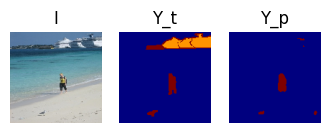

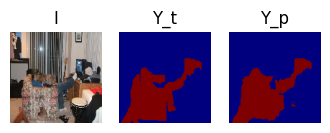

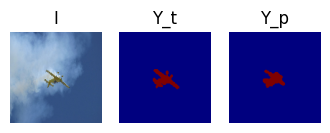

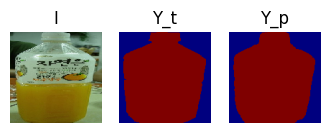

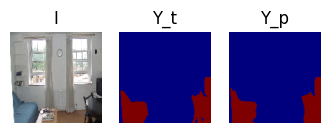

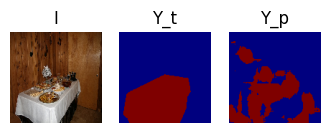

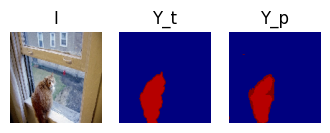

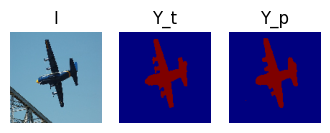

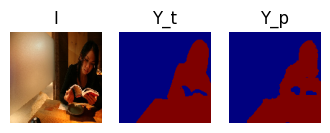

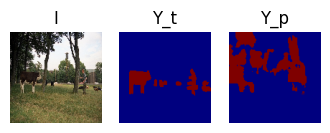

In [ ]:
def mean_iou(y_true, y_pred):
    y_true = np.argmax(y_true, axis=-1).flatten()
    y_pred = np.argmax(y_pred, axis=-1).flatten()
    return jaccard_score(y_true, y_pred, average='macro')

def display(idx):
    img = X_data[idx]
    true_mask = np.argmax(Y_data[idx], axis=-1)
    pred_mask = np.argmax(y_pred[idx], axis=-1)

    plt.figure(figsize=(4,3))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("I")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(true_mask, cmap="jet")
    plt.title("Y_t")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask, cmap="jet")
    plt.title("Y_p")
    plt.axis("off")
    plt.show()

# precision = precision_score(Y_data, y_pred, average='macro', zero_division=0)
# precision, recall, f1_score, _ = precision_recall_fscore_support(Y_data, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Mean IoU: {mean_iou(Y_data, y_pred)}")
for _ in range(10):
    display(np.random.randint(0, len(X_data)))